In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
df = pd.read_csv("heart.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (1025, 14)

Column Names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 723


In [7]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (302, 14)


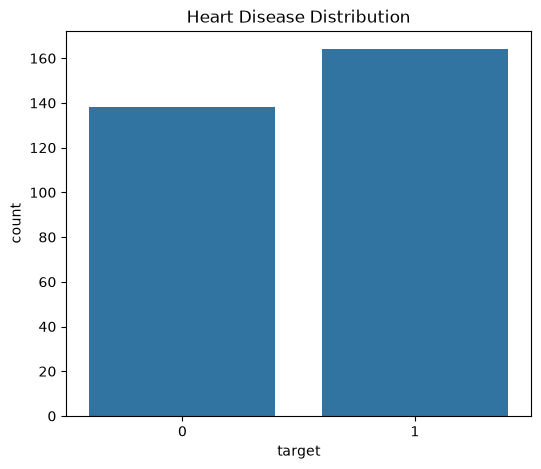

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")

plt.show()

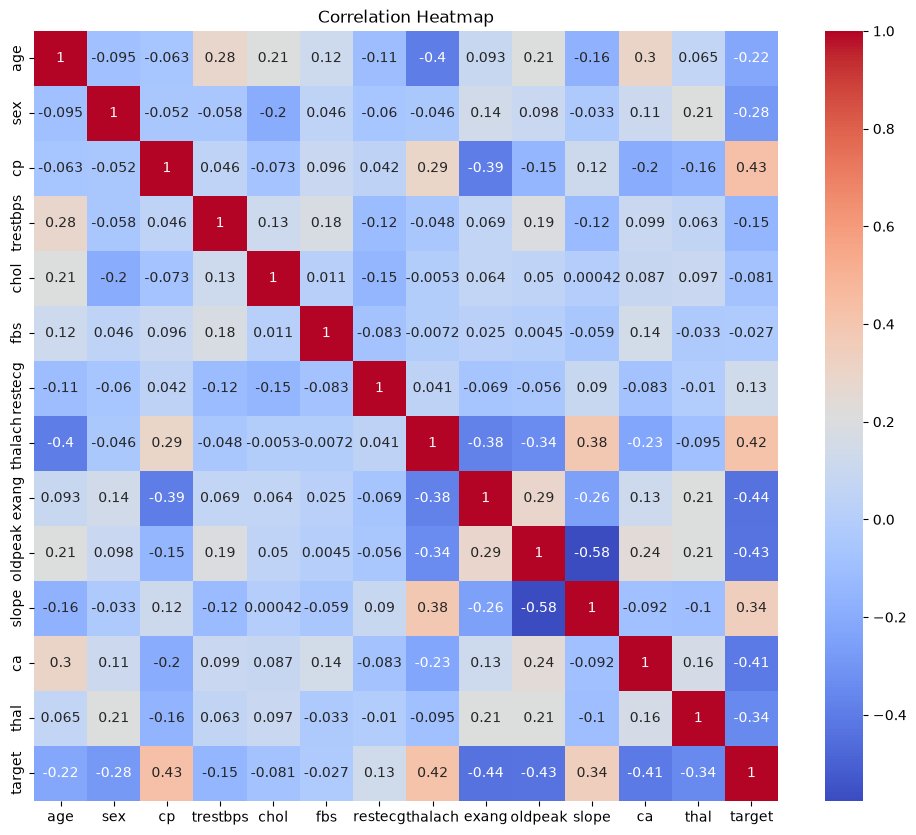

In [9]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

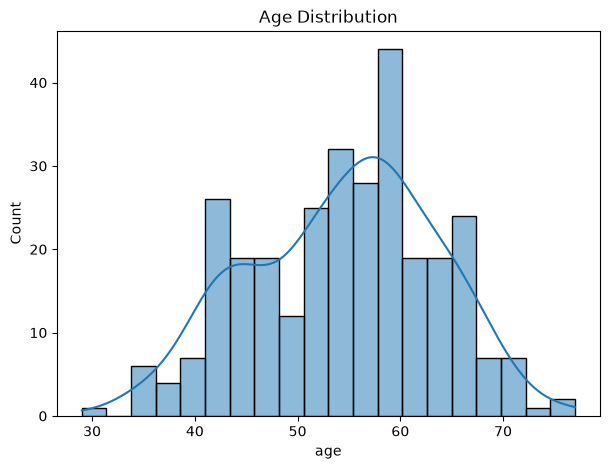

In [10]:
plt.figure(figsize=(7,5))

sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

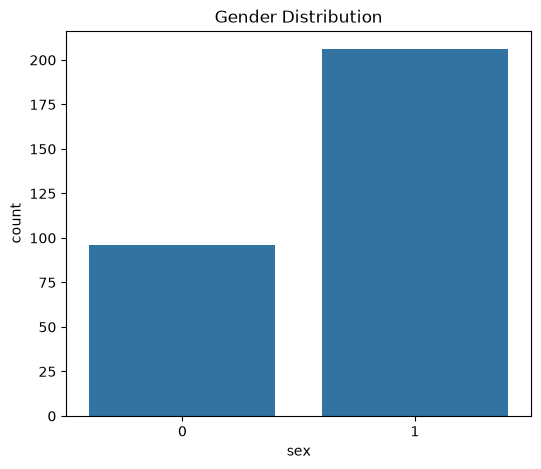

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(x="sex", data=df)

plt.title("Gender Distribution")

plt.show()

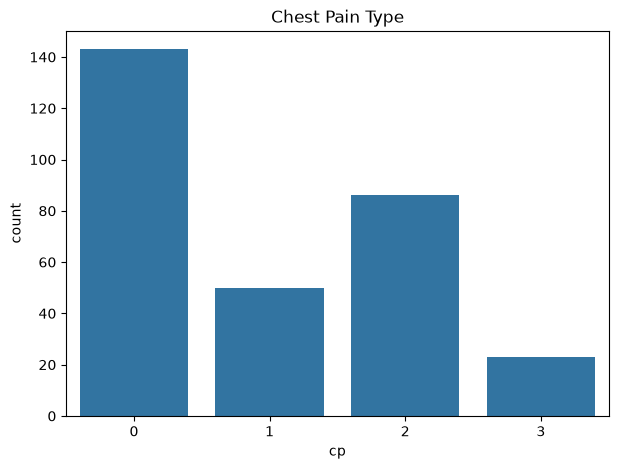

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(x="cp", data=df)

plt.title("Chest Pain Type")

plt.show()

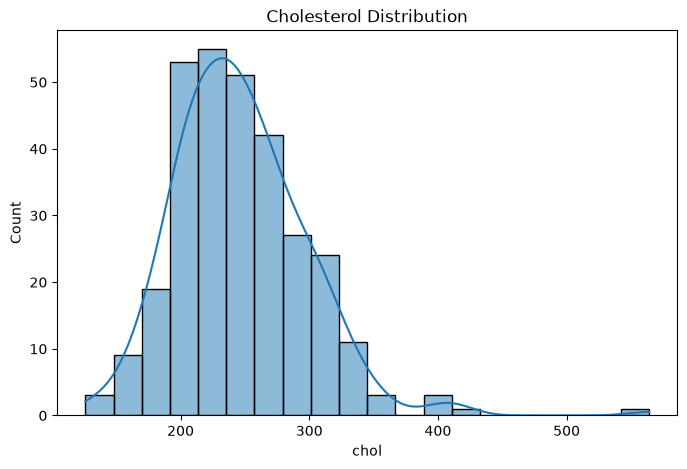

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["chol"], bins=20, kde=True)

plt.title("Cholesterol Distribution")

plt.show()

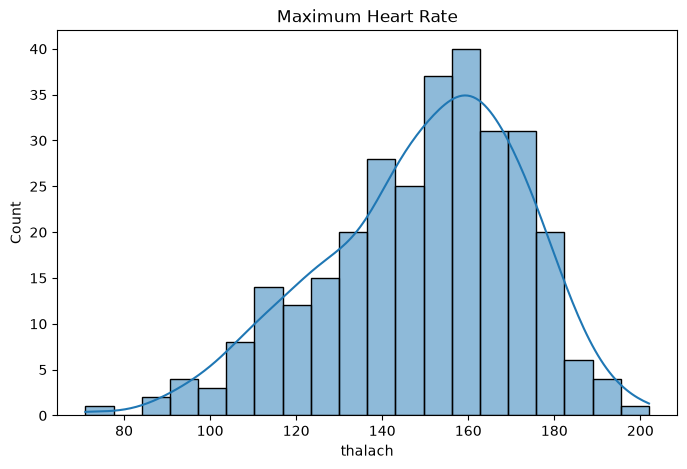

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["thalach"], bins=20, kde=True)

plt.title("Maximum Heart Rate")

plt.show()

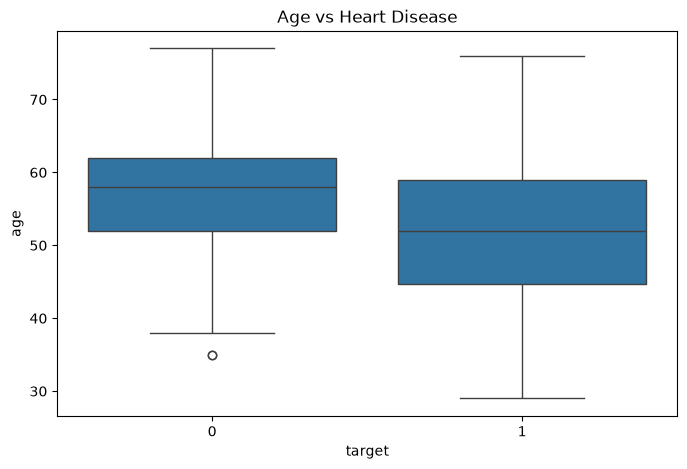

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="age", data=df)

plt.title("Age vs Heart Disease")

plt.show()

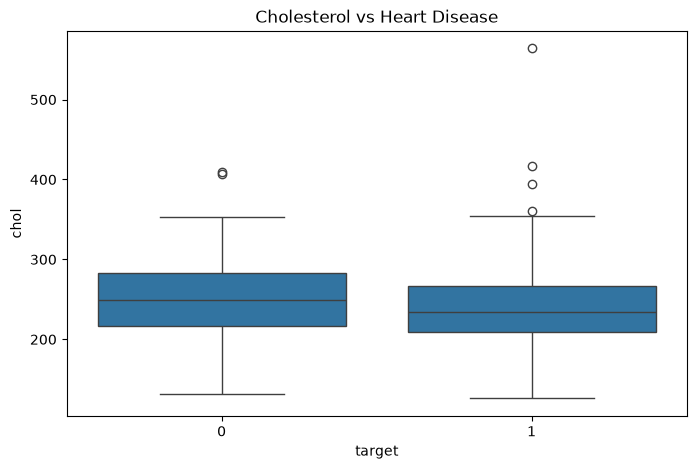

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="chol", data=df)

plt.title("Cholesterol vs Heart Disease")

plt.show()

In [17]:
X = df.drop("target", axis=1)

y = df["target"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [18]:
X_scaled[:5]

array([[-0.26796589,  0.68265615, -0.93520799, -0.37655636, -0.66772815,
        -0.41844626,  0.90165655,  0.80603539, -0.69834428, -0.03712404,
         0.97951442,  1.27497996,  1.11996657],
       [-0.15726042,  0.68265615, -0.93520799,  0.47891019, -0.84191811,
         2.38979311, -1.0025412 ,  0.23749516,  1.43195847,  1.77395808,
        -2.27118179, -0.71491124,  1.11996657],
       [ 1.72473259,  0.68265615, -0.93520799,  0.76406571, -1.40319685,
        -0.41844626,  0.90165655, -1.07452077,  1.43195847,  1.34274805,
        -2.27118179, -0.71491124,  1.11996657],
       [ 0.72838335,  0.68265615, -0.93520799,  0.93515902, -0.84191811,
        -0.41844626,  0.90165655,  0.49989834, -0.69834428, -0.8995441 ,
         0.97951442,  0.28003436,  1.11996657],
       [ 0.83908882, -1.46486632, -0.93520799,  0.36484799,  0.91933586,
         2.38979311,  0.90165655, -1.90546419, -0.69834428,  0.73905401,
        -0.64583368,  2.26992556, -0.51399432]])

In [19]:
print(X.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [20]:
print("="*50)
print("DATA PREPROCESSING COMPLETED")
print("="*50)

print("Total Samples :", len(df))
print("Features :", X.shape[1])
print("Target Variable : Heart Disease")

DATA PREPROCESSING COMPLETED
Total Samples : 302
Features : 13
Target Variable : Heart Disease


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (241, 13)
Testing Shape : (61, 13)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8032786885245902


In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8032786885245902


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7540983606557377


In [25]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.7704918032786885


In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.7868852459016393


In [27]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN"
    ],

    "Accuracy":[

        accuracy_score(y_test, lr_pred),

        accuracy_score(y_test, dt_pred),

        accuracy_score(y_test, rf_pred),

        accuracy_score(y_test, svm_pred),

        accuracy_score(y_test, knn_pred)

    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.803279
1,Decision Tree,0.803279
2,Random Forest,0.754098
3,SVM,0.770492
4,KNN,0.786885


In [28]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.803279
1,Decision Tree,0.803279
4,KNN,0.786885
3,SVM,0.770492
2,Random Forest,0.754098


In [29]:
from sklearn.model_selection import GridSearchCV

params = {

    "n_estimators":[50,100,150],

    "max_depth":[3,5,7,None]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    params,

    cv=5,

    scoring="accuracy"

)

grid.fit(X_train,y_train)

print("Best Parameters :",grid.best_params_)

print("Best Score :",grid.best_score_)

Best Parameters : {'max_depth': 3, 'n_estimators': 50}
Best Score : 0.8589285714285714


In [30]:
best_model = grid.best_estimator_

prediction = best_model.predict(X_test)

print("Accuracy :",accuracy_score(y_test,prediction))

Accuracy : 0.7704918032786885


In [31]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    prediction
))

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



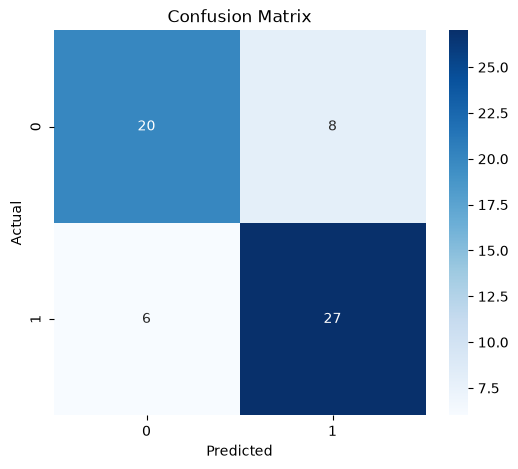

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

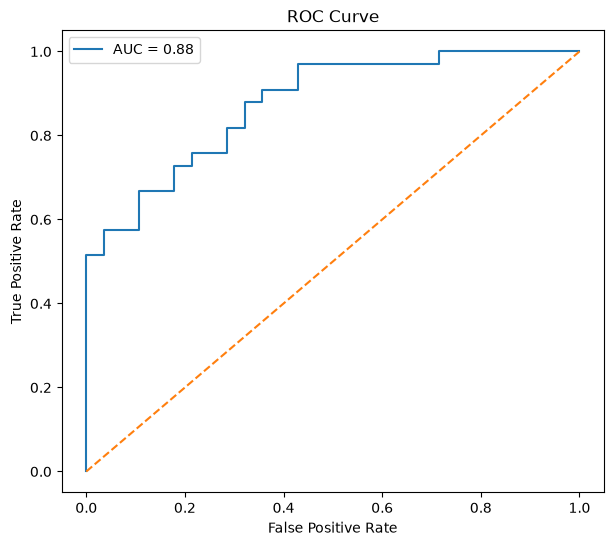

In [33]:
from sklearn.metrics import roc_curve, auc

prob = best_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,prob)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr,tpr,label="AUC = %.2f"%roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [34]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print(importance)

     Feature  Importance
2         cp    0.246484
11        ca    0.156388
8      exang    0.142175
7    thalach    0.117103
12      thal    0.111095
9    oldpeak    0.078833
0        age    0.038776
1        sex    0.031829
4       chol    0.027119
10     slope    0.025621
3   trestbps    0.012209
6    restecg    0.008648
5        fbs    0.003721


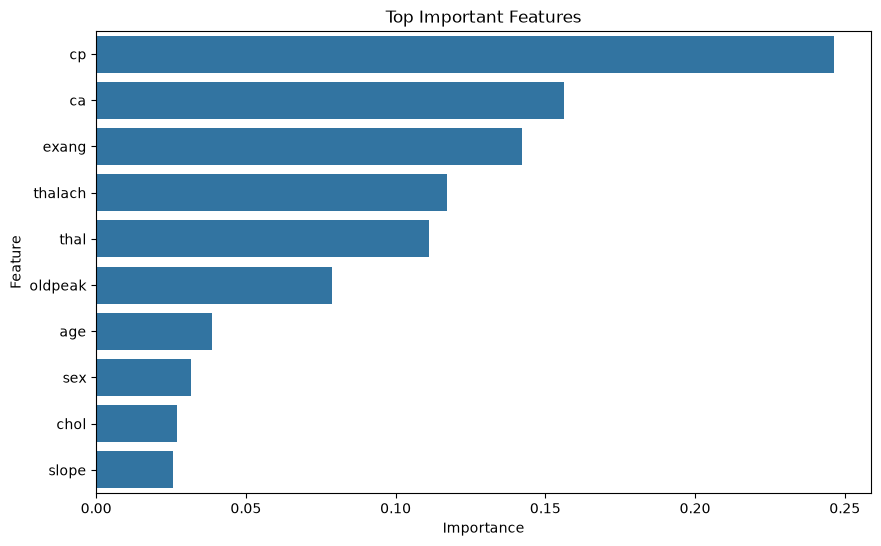

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=importance.head(10)

)

plt.title("Top Important Features")

plt.show()

In [36]:
results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":prediction

})

results.to_csv(

    "heart_predictions.csv",

    index=False

)

print("Predictions Saved")

Predictions Saved


In [37]:
print("="*60)

print("BUSINESS INSIGHTS")

print("="*60)

print("1. Chest pain type is one of the strongest predictors.")

print("2. Maximum heart rate has a significant impact.")

print("3. Cholesterol levels influence heart disease risk.")

print("4. Early diagnosis can reduce health complications.")

print("5. Machine learning assists doctors in decision making.")

BUSINESS INSIGHTS
1. Chest pain type is one of the strongest predictors.
2. Maximum heart rate has a significant impact.
3. Cholesterol levels influence heart disease risk.
4. Early diagnosis can reduce health complications.
5. Machine learning assists doctors in decision making.


In [38]:
print("="*60)

print("PROJECT COMPLETED SUCCESSFULLY")

print("="*60)

print("✓ Data Cleaning")

print("✓ Exploratory Data Analysis")

print("✓ Feature Scaling")

print("✓ Logistic Regression")

print("✓ Decision Tree")

print("✓ Random Forest")

print("✓ SVM")

print("✓ KNN")

print("✓ Hyperparameter Tuning")

print("✓ Model Comparison")

print("✓ Business Insights")

print("✓ Prediction File Saved")

PROJECT COMPLETED SUCCESSFULLY
✓ Data Cleaning
✓ Exploratory Data Analysis
✓ Feature Scaling
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ SVM
✓ KNN
✓ Hyperparameter Tuning
✓ Model Comparison
✓ Business Insights
✓ Prediction File Saved
